# EDA 19: Average Order Value Analysis

This notebook analyzes Average Order Value (AOV), revenue decomposition into order count versus AOV, and AOV variation over time, by month, acquisition channel, payment method, category, and promotion/campaign signals.

AOV is defined as:

`AOV = revenue / number_of_orders`

Findings are exploratory. Future AOV is not known at prediction time, so forecast features in this notebook are shifted before lagging or rolling.

## 1. Setup and file discovery

Locate required and optional CSV files recursively from the current working directory. Missing files are reported clearly and dependent sections continue where possible.

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

ROOT = Path.cwd()
REQUIRED_FILES = ["orders.csv", "order_items.csv", "payments.csv"]
OPTIONAL_FILES = ["customers.csv", "products.csv", "promotions.csv"]
ALL_FILES = REQUIRED_FILES + OPTIONAL_FILES

def normalize_name(value):
    return re.sub(r"[^a-z0-9]+", "", str(value).strip().lower())

def display_warning(message):
    print(f"WARNING: {message}")

def find_csv_files(root, filenames):
    all_csvs = list(root.rglob("*.csv"))
    found = {}
    for filename in filenames:
        target = normalize_name(filename)
        matches = [p for p in all_csvs if normalize_name(p.name) == target]
        matches = sorted(matches, key=lambda p: (len(p.parts), str(p).lower()))
        found[filename] = matches[0] if matches else None
    return found

file_paths = find_csv_files(ROOT, ALL_FILES)
discovery_table = pd.DataFrame(
    {
        "file": list(file_paths.keys()),
        "path": [str(p) if p is not None else None for p in file_paths.values()],
        "required": [name in REQUIRED_FILES for name in file_paths.keys()],
        "status": ["found" if p is not None else "missing" for p in file_paths.values()],
    }
)
display(discovery_table)

for name in REQUIRED_FILES:
    if file_paths.get(name) is None:
        display_warning(f"Required file {name} was not found. Dependent analysis will continue where possible.")
for name in OPTIONAL_FILES:
    if file_paths.get(name) is None:
        print(f"Note: Optional file {name} was not found. Optional AOV cuts using it will be skipped.")

,file,path,required,status
0,orders.csv,D:\Code\Datathon 2026\datathon-2026-round-1\or...,True,found
1,order_items.csv,D:\Code\Datathon 2026\datathon-2026-round-1\or...,True,found
2,payments.csv,D:\Code\Datathon 2026\datathon-2026-round-1\pa...,True,found
3,customers.csv,D:\Code\Datathon 2026\datathon-2026-round-1\cu...,False,found
4,products.csv,D:\Code\Datathon 2026\datathon-2026-round-1\pr...,False,found
5,promotions.csv,D:\Code\Datathon 2026\datathon-2026-round-1\pr...,False,found


## 2. Load required and optional files

Available CSVs are loaded safely with pandas. Initial columns and samples are displayed for schema transparency.

In [2]:
def safe_read_csv(path):
    if path is None:
        return None
    attempts = [
        {"low_memory": False},
        {"encoding": "utf-8-sig", "low_memory": False},
        {"encoding": "latin1", "low_memory": False},
    ]
    last_error = None
    for kwargs in attempts:
        try:
            return pd.read_csv(path, **kwargs)
        except Exception as exc:
            last_error = exc
    display_warning(f"Could not load {path}: {last_error}")
    return None

data = {name: safe_read_csv(path) for name, path in file_paths.items()}
orders = data.get("orders.csv")
order_items = data.get("order_items.csv")
payments = data.get("payments.csv")
customers = data.get("customers.csv")
products = data.get("products.csv")
promotions = data.get("promotions.csv")

load_summary = []
for name, df in data.items():
    load_summary.append(
        {
            "file": name,
            "loaded": df is not None,
            "rows": 0 if df is None else len(df),
            "columns": 0 if df is None else df.shape[1],
        }
    )
display(pd.DataFrame(load_summary))

for name, df in data.items():
    if df is not None:
        print(f"\n{name} columns:")
        print(list(df.columns))
        display(df.head())

,file,loaded,rows,columns
0,orders.csv,True,646945,8
1,order_items.csv,True,714669,7
2,payments.csv,True,646945,4
3,customers.csv,True,121930,7
4,products.csv,True,2412,8
5,promotions.csv,True,50,10



orders.csv columns:
['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method', 'device_type', 'order_source']


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign



order_items.csv columns:
['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,"1,138.2200",0.0000,NaN,NaN
1,2,609,7,"10,166.2500",0.0000,NaN,NaN
2,3,396,3,"11,220.3300",0.0000,NaN,NaN
3,4,635,5,"10,639.2500",0.0000,NaN,NaN
4,6,1935,1,"1,597.8400",0.0000,NaN,NaN


...

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search



products.csv columns:
['product_id', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs']


,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,"11,059.6500","9,704.8429"
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,"9,523.0760","5,393.8703"
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,"15,951.6332","11,371.9193"
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,"15,753.7173","8,573.1730"
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,"15,766.3345","14,063.5704"



promotions.csv columns:
['promo_id', 'promo_name', 'promo_type', 'discount_value', 'start_date', 'end_date', 'applicable_category', 'promo_channel', 'stackable_flag', 'min_order_value']


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0000,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0000,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0000,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0000,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0000,2013-07-30,2013-09-02,Streetwear,online,0,150000


## 3. Identify key, date, revenue, payment, customer, category, and promotion columns

Column detection is based on normalized names, numeric plausibility, date parse quality, and join-key overlap. If fields are missing or ambiguous, warnings are displayed and dependent sections are skipped.

In [3]:
def score_column(col, include_terms=None, exclude_terms=None):
    n = normalize_name(col)
    score = 0
    include_terms = include_terms or []
    exclude_terms = exclude_terms or []
    for term, points in include_terms:
        if normalize_name(term) in n:
            score += points
    for term, points in exclude_terms:
        if normalize_name(term) in n:
            score -= points
    return score

def choose_column_by_terms(df, include_terms, exclude_terms=None, min_score=1):
    if df is None or df.empty:
        return None
    scored = [(score_column(col, include_terms, exclude_terms), col) for col in df.columns]
    scored = sorted(scored, key=lambda x: (x[0], -len(str(x[1]))), reverse=True)
    return scored[0][1] if scored and scored[0][0] >= min_score else None

def choose_numeric_column(df, include_terms, exclude_terms=None, min_score=1):
    if df is None or df.empty:
        return None
    scored = []
    for col in df.columns:
        numeric = pd.to_numeric(df[col], errors="coerce")
        valid_rate = numeric.notna().mean()
        if valid_rate < 0.5 or numeric.nunique(dropna=True) < 2:
            continue
        score = score_column(col, include_terms, exclude_terms) + valid_rate * 3
        scored.append((score, col))
    scored = sorted(scored, reverse=True)
    return scored[0][1] if scored and scored[0][0] >= min_score else None

def choose_date_column(df, preferred_terms=None):
    if df is None or df.empty:
        return None
    preferred_terms = preferred_terms or []
    candidates = []
    for col in df.columns:
        parsed = pd.to_datetime(df[col], errors="coerce")
        valid_rate = parsed.notna().mean()
        unique_count = parsed.nunique(dropna=True)
        name_score = score_column(
            col,
            preferred_terms + [("date", 10), ("time", 4), ("order", 5), ("start", 5), ("end", 5), ("created", 4)],
            [("id", 8), ("zip", 8), ("price", 8), ("amount", 8), ("quantity", 8), ("qty", 8), ("value", 6)],
        )
        if valid_rate >= 0.45 and unique_count >= 1:
            candidates.append((valid_rate * 100 + name_score + min(unique_count, 100) * 0.01, col))
    candidates = sorted(candidates, reverse=True)
    return candidates[0][1] if candidates else None

def choose_common_key(left_df, right_df, left_terms, right_terms=None):
    if left_df is None or right_df is None:
        return None, None
    right_terms = right_terms or left_terms
    left_candidates = [
        col for col in left_df.columns
        if score_column(col, left_terms, [("date", 5), ("amount", 5), ("price", 5), ("quantity", 5), ("qty", 5)]) > 0
    ]
    right_candidates = [
        col for col in right_df.columns
        if score_column(col, right_terms, [("date", 5), ("amount", 5), ("price", 5), ("quantity", 5), ("qty", 5)]) > 0
    ]
    best = None
    for lcol in left_candidates:
        lvals = left_df[lcol].dropna().astype(str)
        if lvals.empty:
            continue
        lsample = set(lvals.head(10000))
        for rcol in right_candidates:
            rvals = right_df[rcol].dropna().astype(str)
            if rvals.empty:
                continue
            rsample = set(rvals.head(10000))
            overlap = len(lsample.intersection(rsample))
            score = overlap + score_column(lcol, left_terms) + score_column(rcol, right_terms)
            if best is None or score > best[0]:
                best = (score, lcol, rcol, overlap)
    if best is None or best[0] <= 0:
        return None, None
    return best[1], best[2]

order_terms = [("orderid", 14), ("order", 8), ("invoice", 6), ("transaction", 6), ("receipt", 4)]
customer_terms = [("customerid", 14), ("customer", 8), ("clientid", 12), ("client", 6), ("user", 4), ("buyer", 4)]
product_terms = [("productid", 14), ("product", 8), ("sku", 6), ("itemid", 8), ("item", 4)]
promo_terms = [("promoid", 14), ("promo", 10), ("campaign", 9), ("promotion", 9), ("coupon", 6), ("offer", 5)]

order_id_col = choose_column_by_terms(orders, order_terms, [("date", 6), ("amount", 4), ("status", 3)], min_score=4)
order_date_col = choose_date_column(orders, [("orderdate", 16), ("order", 8)])
order_customer_col, customer_customer_col = choose_common_key(orders, customers, customer_terms) if customers is not None else (None, None)
item_order_col, order_order_col_for_items = choose_common_key(order_items, orders, order_terms)
payment_order_col, order_order_col_for_payments = choose_common_key(payments, orders, order_terms)
item_product_col, product_product_col = choose_common_key(order_items, products, product_terms) if products is not None else (None, None)

quantity_col = choose_numeric_column(order_items, [("quantity", 10), ("qty", 10), ("units", 6)], [("id", 10), ("price", 6), ("amount", 4)], min_score=5)
price_col = choose_numeric_column(order_items, [("unitprice", 12), ("price", 10), ("sellingprice", 10), ("saleprice", 10)], [("id", 10), ("cost", 8), ("discount", 8), ("quantity", 8), ("qty", 8)], min_score=5)
discount_col = choose_numeric_column(order_items, [("discount", 10), ("promo", 3)], [("id", 5), ("quantity", 8), ("qty", 8), ("price", 5)], min_score=5)
direct_order_revenue_col = choose_numeric_column(
    orders,
    [("revenue", 12), ("sales", 10), ("amount", 8), ("total", 8), ("subtotal", 6), ("net", 6), ("ordervalue", 10)],
    [("discount", 10), ("price", 8), ("cost", 8), ("quantity", 10), ("qty", 10), ("id", 10), ("zip", 10)],
    min_score=5,
)
direct_item_revenue_col = choose_numeric_column(
    order_items,
    [("revenue", 12), ("sales", 10), ("total", 8), ("subtotal", 6), ("net", 6)],
    [("discount", 10), ("price", 8), ("cost", 8), ("quantity", 10), ("qty", 10), ("id", 10)],
    min_score=5,
)
payment_amount_col = choose_numeric_column(
    payments,
    [("paymentvalue", 14), ("paymentamount", 12), ("amount", 9), ("value", 8), ("paid", 6), ("total", 6)],
    [("id", 8), ("installment", 8), ("quantity", 8), ("qty", 8)],
    min_score=5,
)
order_payment_method_col = choose_column_by_terms(orders, [("paymentmethod", 12), ("payment", 8), ("method", 7)], [("id", 8), ("amount", 8), ("date", 8)], min_score=6)
payment_method_col = choose_column_by_terms(payments, [("paymentmethod", 12), ("payment", 8), ("method", 7)], [("id", 8), ("amount", 8), ("date", 8), ("value", 8)], min_score=6)
payment_status_col = choose_column_by_terms(payments, [("status", 10), ("state", 5)], [("id", 8), ("amount", 8), ("value", 8)], min_score=5)
order_status_col = choose_column_by_terms(orders, [("status", 10), ("state", 5)], [("id", 8), ("amount", 8), ("date", 8)], min_score=5)
acquisition_col = choose_column_by_terms(customers, [("acquisitionchannel", 16), ("acquisition", 12), ("channel", 10), ("source", 8), ("campaign", 5)], [("id", 8), ("date", 8), ("zip", 7)], min_score=6) if customers is not None else None
order_source_col = choose_column_by_terms(orders, [("ordersource", 12), ("source", 8), ("channel", 6)], [("id", 8), ("date", 8), ("amount", 8)], min_score=6)
category_col = choose_column_by_terms(products, [("category", 12), ("department", 8), ("class", 6), ("segment", 4)], [("id", 8), ("price", 6), ("cost", 6)], min_score=6) if products is not None else None
item_promo_cols = [col for col in order_items.columns if score_column(col, promo_terms, [("date", 6), ("amount", 5)]) >= 6] if order_items is not None else []
promo_id_col = choose_column_by_terms(promotions, promo_terms, [("date", 6), ("amount", 5), ("value", 5)], min_score=6) if promotions is not None else None
promo_start_col = choose_date_column(promotions, [("startdate", 16), ("start", 10)]) if promotions is not None else None
promo_end_col = choose_date_column(promotions, [("enddate", 16), ("end", 10)]) if promotions is not None else None

detected = pd.DataFrame(
    [
        {"field": "orders.order_id", "column": order_id_col},
        {"field": "orders.order_date", "column": order_date_col},
        {"field": "orders.customer_id", "column": order_customer_col},
        {"field": "customers.customer_id", "column": customer_customer_col},
        {"field": "order_items.order_id", "column": item_order_col},
        {"field": "payments.order_id", "column": payment_order_col},
        {"field": "order_items.product_id", "column": item_product_col},
        {"field": "products.product_id", "column": product_product_col},
        {"field": "order_items.quantity", "column": quantity_col},
        {"field": "order_items.price", "column": price_col},
        {"field": "order_items.discount", "column": discount_col},
        {"field": "orders.direct_revenue", "column": direct_order_revenue_col},
        {"field": "order_items.direct_revenue", "column": direct_item_revenue_col},
        {"field": "payments.payment_amount", "column": payment_amount_col},
        {"field": "payments.payment_method", "column": payment_method_col},
        {"field": "orders.payment_method", "column": order_payment_method_col},
        {"field": "payments.payment_status", "column": payment_status_col},
        {"field": "orders.order_status", "column": order_status_col},
        {"field": "customers.acquisition_channel", "column": acquisition_col},
        {"field": "orders.order_source", "column": order_source_col},
        {"field": "products.category", "column": category_col},
        {"field": "order_items.promotion_columns", "column": ", ".join(item_promo_cols) if item_promo_cols else None},
        {"field": "promotions.promo_id", "column": promo_id_col},
        {"field": "promotions.start_date", "column": promo_start_col},
        {"field": "promotions.end_date", "column": promo_end_col},
    ]
)
display(detected)

required_ready = True
if orders is None:
    display_warning("orders.csv is required for AOV analysis.")
    required_ready = False
if order_id_col is None:
    display_warning("Could not identify order ID.")
    required_ready = False
if order_date_col is None:
    display_warning("Could not identify order date.")
    required_ready = False
if direct_order_revenue_col is None and direct_item_revenue_col is None and not (quantity_col is not None and price_col is not None) and payment_amount_col is None:
    display_warning("Could not identify or infer revenue from orders, order_items, or payments.")

,field,column
0,orders.order_id,order_id
1,orders.order_date,order_date
2,orders.customer_id,customer_id
3,customers.customer_id,customer_id
4,order_items.order_id,order_id
5,payments.order_id,order_id
6,order_items.product_id,product_id
7,products.product_id,product_id
8,order_items.quantity,quantity
9,order_items.price,unit_price


## 4. Build order-level revenue dataset

Start from `orders.csv`, aggregate item and payment data to order level, compare available monetary sources, and choose the most reliable source for AOV analysis.

In [4]:
order_level = pd.DataFrame()
items_work = pd.DataFrame()
item_agg = pd.DataFrame()
payment_agg = pd.DataFrame()
category_order = pd.DataFrame()
revenue_comparison = pd.DataFrame()
selected_revenue_source = "not available"
selected_revenue_reason = "No usable revenue source was identified."
excluded_status_count = 0

if required_ready:
    orders_work = orders.copy()
    orders_work["_order_id"] = orders_work[order_id_col].astype(str)
    orders_work["order_date"] = pd.to_datetime(orders_work[order_date_col], errors="coerce")
    order_level = orders_work[["_order_id", "order_date"]].drop_duplicates("_order_id").copy()

    if order_customer_col is not None:
        orders_work["_customer_id"] = orders_work[order_customer_col].astype(str)
        order_level = order_level.merge(orders_work[["_order_id", "_customer_id"]].drop_duplicates("_order_id"), on="_order_id", how="left")
    if order_payment_method_col is not None:
        order_level = order_level.merge(orders_work[["_order_id", order_payment_method_col]].drop_duplicates("_order_id"), on="_order_id", how="left")
        order_level = order_level.rename(columns={order_payment_method_col: "orders_payment_method"})
    if order_status_col is not None:
        order_level = order_level.merge(orders_work[["_order_id", order_status_col]].drop_duplicates("_order_id"), on="_order_id", how="left")
        order_level = order_level.rename(columns={order_status_col: "order_status"})
        bad_status_pattern = r"cancel|fail|refund|void|declin|chargeback"
        order_level["excluded_status_flag"] = order_level["order_status"].astype(str).str.lower().str.contains(bad_status_pattern, regex=True, na=False)
    else:
        order_level["excluded_status_flag"] = False

    if direct_order_revenue_col is not None:
        direct_order = orders_work[["_order_id", direct_order_revenue_col]].drop_duplicates("_order_id").copy()
        direct_order["orders_direct_revenue"] = pd.to_numeric(direct_order[direct_order_revenue_col], errors="coerce")
        order_level = order_level.merge(direct_order[["_order_id", "orders_direct_revenue"]], on="_order_id", how="left")

    if order_items is not None and item_order_col is not None:
        items_work = order_items.copy()
        items_work["_order_id"] = items_work[item_order_col].astype(str)
        if item_product_col is not None:
            items_work["_product_id"] = items_work[item_product_col].astype(str)
        if direct_item_revenue_col is not None:
            items_work["item_revenue"] = pd.to_numeric(items_work[direct_item_revenue_col], errors="coerce")
        elif quantity_col is not None and price_col is not None:
            qty = pd.to_numeric(items_work[quantity_col], errors="coerce")
            price = pd.to_numeric(items_work[price_col], errors="coerce")
            discount = pd.to_numeric(items_work[discount_col], errors="coerce").fillna(0) if discount_col is not None else 0
            items_work["item_revenue"] = qty * price
        else:
            items_work["item_revenue"] = np.nan
        items_work["item_quantity"] = pd.to_numeric(items_work[quantity_col], errors="coerce") if quantity_col is not None else np.nan
        promo_flags = []
        for col in item_promo_cols:
            if col in items_work.columns:
                promo_flags.append(items_work[col].notna())
        if discount_col is not None:
            promo_flags.append(pd.to_numeric(items_work[discount_col], errors="coerce").fillna(0) > 0)
        items_work["has_item_promo"] = np.logical_or.reduce(promo_flags) if promo_flags else False

        item_agg = items_work.groupby("_order_id", as_index=False).agg(
            item_revenue=("item_revenue", "sum"),
            item_count=("item_revenue", "size"),
            total_quantity=("item_quantity", "sum"),
            has_item_promo=("has_item_promo", "max"),
        )
        order_level = order_level.merge(item_agg, on="_order_id", how="left")

    if payments is not None and payment_order_col is not None and payment_amount_col is not None:
        payments_work = payments.copy()
        payments_work["_order_id"] = payments_work[payment_order_col].astype(str)
        payments_work["payment_amount"] = pd.to_numeric(payments_work[payment_amount_col], errors="coerce")
        if payment_status_col is not None:
            payments_work["payment_status"] = payments_work[payment_status_col].astype(str)
            bad_status_pattern = r"cancel|fail|refund|void|declin|chargeback"
            payments_work["excluded_payment_status_flag"] = payments_work["payment_status"].str.lower().str.contains(bad_status_pattern, regex=True, na=False)
            payments_for_amount = payments_work.loc[~payments_work["excluded_payment_status_flag"]].copy()
        else:
            payments_work["payment_status"] = np.nan
            payments_work["excluded_payment_status_flag"] = False
            payments_for_amount = payments_work.copy()
        if payment_method_col is not None:
            payments_work["payment_method_clean"] = payments_work[payment_method_col].astype(str)
        else:
            payments_work["payment_method_clean"] = np.nan
        payment_method_mode = payments_work.groupby("_order_id")["payment_method_clean"].agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan).rename("payment_method").reset_index()
        payment_agg = payments_for_amount.groupby("_order_id", as_index=False).agg(
            payment_amount=("payment_amount", "sum"),
            payment_records=("payment_amount", "size"),
        )
        excluded_status_count = int(payments_work["excluded_payment_status_flag"].sum())
        order_level = order_level.merge(payment_agg, on="_order_id", how="left")
        order_level = order_level.merge(payment_method_mode, on="_order_id", how="left")

    if "payment_method" not in order_level.columns:
        order_level["payment_method"] = np.nan
    if "orders_payment_method" in order_level.columns:
        order_level["payment_method"] = order_level["payment_method"].fillna(order_level["orders_payment_method"])
    order_level["payment_method"] = order_level["payment_method"].fillna("Unknown").astype(str)

    if customers is not None and order_customer_col is not None and customer_customer_col is not None:
        customers_work = customers.copy()
        customers_work["_customer_id"] = customers_work[customer_customer_col].astype(str)
        if acquisition_col is not None:
            channel_dim = customers_work[["_customer_id", acquisition_col]].drop_duplicates("_customer_id")
            order_level = order_level.merge(channel_dim, on="_customer_id", how="left")
            order_level = order_level.rename(columns={acquisition_col: "acquisition_channel"})
    if "acquisition_channel" not in order_level.columns:
        if order_source_col is not None and order_source_col in orders_work.columns:
            source_dim = orders_work[["_order_id", order_source_col]].drop_duplicates("_order_id")
            order_level = order_level.merge(source_dim, on="_order_id", how="left")
            order_level = order_level.rename(columns={order_source_col: "acquisition_channel"})
        else:
            order_level["acquisition_channel"] = np.nan
    order_level["acquisition_channel"] = order_level["acquisition_channel"].fillna("Unknown").astype(str)

    if promotions is not None and promo_start_col is not None and promo_end_col is not None:
        promos = promotions.copy()
        promos["_promo_start"] = pd.to_datetime(promos[promo_start_col], errors="coerce")
        promos["_promo_end"] = pd.to_datetime(promos[promo_end_col], errors="coerce")
        valid_promos = promos.dropna(subset=["_promo_start", "_promo_end"]).copy()
        order_level["in_promotion_calendar_window"] = False
        if not valid_promos.empty:
            order_dates = order_level["order_date"]
            promo_flag = pd.Series(False, index=order_level.index)
            for promo_start, promo_end in valid_promos[["_promo_start", "_promo_end"]].itertuples(index=False, name=None):
                promo_flag = promo_flag | ((order_dates >= promo_start) & (order_dates <= promo_end))
            order_level["in_promotion_calendar_window"] = promo_flag.fillna(False)
    else:
        order_level["in_promotion_calendar_window"] = False
    if "has_item_promo" not in order_level.columns:
        order_level["has_item_promo"] = False
    order_level["is_promo_order"] = order_level["has_item_promo"].fillna(False).astype(bool) | order_level["in_promotion_calendar_window"].fillna(False).astype(bool)

    if "item_revenue" in order_level.columns and "payment_amount" in order_level.columns:
        comp = order_level[["item_revenue", "payment_amount"]].dropna().copy()
        if not comp.empty:
            comp["absolute_difference"] = (comp["item_revenue"] - comp["payment_amount"]).abs()
            comp["relative_difference"] = comp["absolute_difference"] / comp[["item_revenue", "payment_amount"]].abs().max(axis=1).replace(0, np.nan)
            revenue_comparison = pd.DataFrame(
                [
                    {
                        "overlapping_orders": len(comp),
                        "item_revenue_total": comp["item_revenue"].sum(),
                        "payment_amount_total": comp["payment_amount"].sum(),
                        "correlation": comp["item_revenue"].corr(comp["payment_amount"]),
                        "median_absolute_difference": comp["absolute_difference"].median(),
                        "median_relative_difference": comp["relative_difference"].median(),
                        "share_within_1pct": (comp["relative_difference"] <= 0.01).mean(),
                    }
                ]
            )
            display(revenue_comparison)

    item_coverage = order_level["item_revenue"].notna().mean() if "item_revenue" in order_level.columns else 0
    payment_coverage = order_level["payment_amount"].notna().mean() if "payment_amount" in order_level.columns else 0
    direct_coverage = order_level["orders_direct_revenue"].notna().mean() if "orders_direct_revenue" in order_level.columns else 0
    if direct_coverage >= 0.9:
        order_level["order_revenue"] = order_level["orders_direct_revenue"]
        selected_revenue_source = "orders direct revenue"
        selected_revenue_reason = "A direct order-level revenue field had high coverage."
    elif item_coverage >= 0.8:
        order_level["order_revenue"] = order_level["item_revenue"]
        selected_revenue_source = "item-derived revenue"
        selected_revenue_reason = "Item quantity, price, and discount fields were available and matched most orders."
    elif payment_coverage >= 0.5:
        order_level["order_revenue"] = order_level["payment_amount"]
        selected_revenue_source = "payment amount"
        selected_revenue_reason = "Payment amount was the best available monetary source."
    elif "item_revenue" in order_level.columns:
        order_level["order_revenue"] = order_level["item_revenue"]
        selected_revenue_source = "item-derived revenue with limited coverage"
        selected_revenue_reason = "Used item-derived revenue despite limited coverage because no stronger source was available."
    else:
        order_level["order_revenue"] = np.nan

    print(f"Selected revenue source: {selected_revenue_source}")
    print(f"Reason: {selected_revenue_reason}")
    display(order_level.head(10))
else:
    display_warning("Skipping order-level dataset construction because order ID/date could not be identified.")

,overlapping_orders,item_revenue_total,payment_amount_total,correlation,median_absolute_difference,median_relative_difference,share_within_1pct
0,646945,"16,430,476,585.5300","15,680,869,265.4300",0.9947,0.0000,0.0000,0.6269


Selected revenue source: item-derived revenue
Reason: Item quantity, price, and discount fields were available and matched most orders.


,_order_id,order_date,_customer_id,orders_payment_method,order_status,excluded_status_flag,item_revenue,item_count,total_quantity,has_item_promo,payment_amount,payment_records,payment_method,acquisition_channel,in_promotion_calendar_window,is_promo_order,order_revenue
0,1,2012-07-04,58578,credit_card,delivered,False,"7,967.5400",1,7,False,"7,967.5400",1,credit_card,social_media,False,False,"7,967.5400"
1,2,2012-07-04,58621,cod,returned,False,"71,163.7500",1,7,False,"71,163.7500",1,cod,social_media,False,False,"71,163.7500"
2,3,2012-07-04,58811,credit_card,delivered,False,"33,660.9900",1,3,False,"33,660.9900",1,credit_card,direct,False,False,"33,660.9900"
3,4,2012-07-04,59453,credit_card,delivered,False,"53,196.2500",1,5,False,"53,196.2500",1,credit_card,direct,False,False,"53,196.2500"
4,6,2012-07-06,57821,paypal,delivered,False,"1,597.8400",1,1,False,"1,597.8400",1,paypal,social_media,False,False,"1,597.8400"
5,7,2012-07-06,57820,credit_card,delivered,False,"9,800.9400",1,6,False,"9,800.9400",1,credit_card,paid_search,False,False,"9,800.9400"
6,8,2012-07-06,57818,credit_card,delivered,False,"16,187.5600",2,10,False,"16,187.5600",1,credit_card,paid_search,False,False,"16,187.5600"
7,9,2012-07-06,49102,apple_pay,delivered,False,"32,397.1200",1,8,False,"32,397.1200",1,apple_pay,social_media,False,False,"32,397.1200"
8,10,2012-07-06,49101,paypal,delivered,False,"19,886.8500",1,5,False,"19,886.8500",1,paypal,email_campaign,False,False,"19,886.8500"
9,13,2012-07-06,40638,credit_card,delivered,False,"36,037.6800",1,6,False,"36,037.6800",1,credit_card,email_campaign,False,False,"36,037.6800"


## 5. Join and aggregation quality checks

Report order-level coverage, duplicated IDs, missing revenue, optional join coverage, and status filtering/flagging.

In [5]:
quality = {}

if not order_level.empty:
    order_ids = set(order_level["_order_id"].dropna().astype(str))
    item_rows_matched = item_rows_unmatched = np.nan
    if order_items is not None and item_order_col is not None:
        item_ids = order_items[item_order_col].dropna().astype(str)
        item_rows_matched = int(item_ids.isin(order_ids).sum())
        item_rows_unmatched = int((~item_ids.isin(order_ids)).sum())
    payment_rows_matched = payment_rows_unmatched = np.nan
    if payments is not None and payment_order_col is not None:
        payment_ids = payments[payment_order_col].dropna().astype(str)
        payment_rows_matched = int(payment_ids.isin(order_ids).sum())
        payment_rows_unmatched = int((~payment_ids.isin(order_ids)).sum())

    customer_matched = np.nan
    customer_unmatched = np.nan
    if customers is not None and "_customer_id" in order_level.columns:
        customer_ids = set(customers[customer_customer_col].dropna().astype(str)) if customer_customer_col is not None else set()
        customer_matched = int(order_level["_customer_id"].astype(str).isin(customer_ids).sum())
        customer_unmatched = int((~order_level["_customer_id"].astype(str).isin(customer_ids)).sum())

    quality = {
        "number_of_orders": len(order_level),
        "duplicated_order_ids_in_orders": int(orders[order_id_col].duplicated().sum()) if orders is not None and order_id_col is not None else np.nan,
        "orders_with_invalid_dates": int(order_level["order_date"].isna().sum()),
        "orders_with_missing_revenue": int(order_level["order_revenue"].isna().sum()),
        "orders_with_zero_revenue": int((order_level["order_revenue"] == 0).sum()),
        "orders_with_negative_revenue": int((order_level["order_revenue"] < 0).sum()),
        "order_items_rows_matched_to_orders": item_rows_matched,
        "order_items_rows_unmatched_to_orders": item_rows_unmatched,
        "payments_rows_matched_to_orders": payment_rows_matched,
        "payments_rows_unmatched_to_orders": payment_rows_unmatched,
        "customer_rows_matched_for_acquisition": customer_matched,
        "customer_rows_unmatched_for_acquisition": customer_unmatched,
        "excluded_payment_status_records": excluded_status_count,
        "orders_flagged_by_bad_order_status": int(order_level["excluded_status_flag"].sum()) if "excluded_status_flag" in order_level.columns else 0,
        "selected_revenue_source": selected_revenue_source,
    }
    display(pd.DataFrame([quality]).T.rename(columns={0: "value"}))
else:
    display_warning("Join quality checks skipped because order-level data is unavailable.")

,value
number_of_orders,646945
duplicated_order_ids_in_orders,0
orders_with_invalid_dates,0
orders_with_missing_revenue,0
orders_with_zero_revenue,0
orders_with_negative_revenue,0
order_items_rows_matched_to_orders,714669
order_items_rows_unmatched_to_orders,0
payments_rows_matched_to_orders,646945
payments_rows_unmatched_to_orders,0


## 6. Daily revenue, order count, and AOV time series

Daily revenue, number of orders, and AOV are aggregated to a continuous date index. Days with no orders are kept as zero-order days with undefined AOV.

In [6]:
daily_ts = pd.DataFrame()
missing_dates_count = np.nan
overall_aov = np.nan

if not order_level.empty:
    valid_orders = order_level.dropna(subset=["order_date"]).copy()
    valid_orders = valid_orders.loc[~valid_orders["excluded_status_flag"].fillna(False)].copy()
    valid_orders["date"] = valid_orders["order_date"].dt.floor("D")
    daily_ts = valid_orders.groupby("date").agg(
        revenue=("order_revenue", "sum"),
        number_of_orders=("_order_id", "nunique"),
    ).sort_index()
    full_index = pd.date_range(daily_ts.index.min(), daily_ts.index.max(), freq="D")
    missing_dates_count = int(len(full_index.difference(daily_ts.index)))
    daily_ts = daily_ts.reindex(full_index)
    daily_ts.index.name = "date"
    daily_ts[["revenue", "number_of_orders"]] = daily_ts[["revenue", "number_of_orders"]].fillna(0)
    daily_ts["AOV"] = daily_ts["revenue"] / daily_ts["number_of_orders"].replace(0, np.nan)
    daily_ts["month"] = daily_ts.index.to_period("M").to_timestamp()
    daily_ts["month_of_year"] = daily_ts.index.month
    daily_ts["weekday_name"] = daily_ts.index.day_name()
    overall_aov = daily_ts["revenue"].sum() / daily_ts["number_of_orders"].sum() if daily_ts["number_of_orders"].sum() else np.nan

    summary_stats = {
        "start_date": daily_ts.index.min().date(),
        "end_date": daily_ts.index.max().date(),
        "calendar_days": len(daily_ts),
        "missing_dates_filled_as_zero_order_days": missing_dates_count,
        "total_revenue": daily_ts["revenue"].sum(),
        "total_orders": daily_ts["number_of_orders"].sum(),
        "overall_AOV": overall_aov,
        "average_daily_AOV_on_order_days": daily_ts.loc[daily_ts["number_of_orders"] > 0, "AOV"].mean(),
        "median_daily_AOV_on_order_days": daily_ts.loc[daily_ts["number_of_orders"] > 0, "AOV"].median(),
        "min_daily_AOV_on_order_days": daily_ts.loc[daily_ts["number_of_orders"] > 0, "AOV"].min(),
        "max_daily_AOV_on_order_days": daily_ts.loc[daily_ts["number_of_orders"] > 0, "AOV"].max(),
    }
    display(pd.DataFrame([summary_stats]).T.rename(columns={0: "value"}))
    display(daily_ts.head(10).reset_index())
    display(daily_ts.tail(10).reset_index())
else:
    display_warning("Daily time series skipped because order-level data is unavailable.")

,value
start_date,2012-07-04
end_date,2022-12-31
calendar_days,3833
missing_dates_filled_as_zero_order_days,0
total_revenue,"14,914,585,579.3400"
total_orders,587483
overall_AOV,"25,387.2633"
average_daily_AOV_on_order_days,"26,738.9732"
median_daily_AOV_on_order_days,"26,705.1614"
min_daily_AOV_on_order_days,"10,926.7429"


,date,revenue,number_of_orders,AOV,month,month_of_year,weekday_name
0,2012-07-04,"4,968,762.1200",153,"32,475.5694",2012-07-01,7,Wednesday
1,2012-07-05,"2,520,721.7900",88,"28,644.5658",2012-07-01,7,Thursday
2,2012-07-06,"2,646,490.5500",82,"32,274.2750",2012-07-01,7,Friday
3,2012-07-07,"2,337,896.9600",65,"35,967.6455",2012-07-01,7,Saturday
4,2012-07-08,"2,199,273.3700",83,"26,497.2695",2012-07-01,7,Sunday
5,2012-07-09,"2,909,927.1800",117,"24,871.1725",2012-07-01,7,Monday
6,2012-07-10,"4,809,139.3800",165,"29,146.2993",2012-07-01,7,Tuesday
7,2012-07-11,"5,279,686.0500",205,"25,754.5661",2012-07-01,7,Wednesday
8,2012-07-12,"5,418,901.4000",226,"23,977.4398",2012-07-01,7,Thursday
9,2012-07-13,"4,767,890.6400",183,"26,054.0472",2012-07-01,7,Friday


,date,revenue,number_of_orders,AOV,month,month_of_year,weekday_name
0,2022-12-22,"1,620,864.6200",73,"22,203.6249",2022-12-01,12,Thursday
1,2022-12-23,"1,220,681.7400",63,"19,375.9006",2022-12-01,12,Friday
2,2022-12-24,"1,341,462.1500",73,"18,376.1938",2022-12-01,12,Saturday
3,2022-12-25,"967,338.9900",64,"15,114.6717",2022-12-01,12,Sunday
4,2022-12-26,"1,918,127.6100",91,"21,078.3254",2022-12-01,12,Monday
5,2022-12-27,"1,887,751.0000",97,"19,461.3505",2022-12-01,12,Tuesday
6,2022-12-28,"3,157,095.6900",144,"21,924.2756",2022-12-01,12,Wednesday
7,2022-12-29,"2,535,988.7000",126,"20,126.8944",2022-12-01,12,Thursday
8,2022-12-30,"2,582,817.9300",97,"26,626.9890",2022-12-01,12,Friday
9,2022-12-31,"2,356,468.9600",72,"32,728.7356",2022-12-01,12,Saturday


## 7. AOV over time

Plot AOV over time with 7-day, 30-day, and 90-day rolling means to inspect trend, stability, and periods of change.

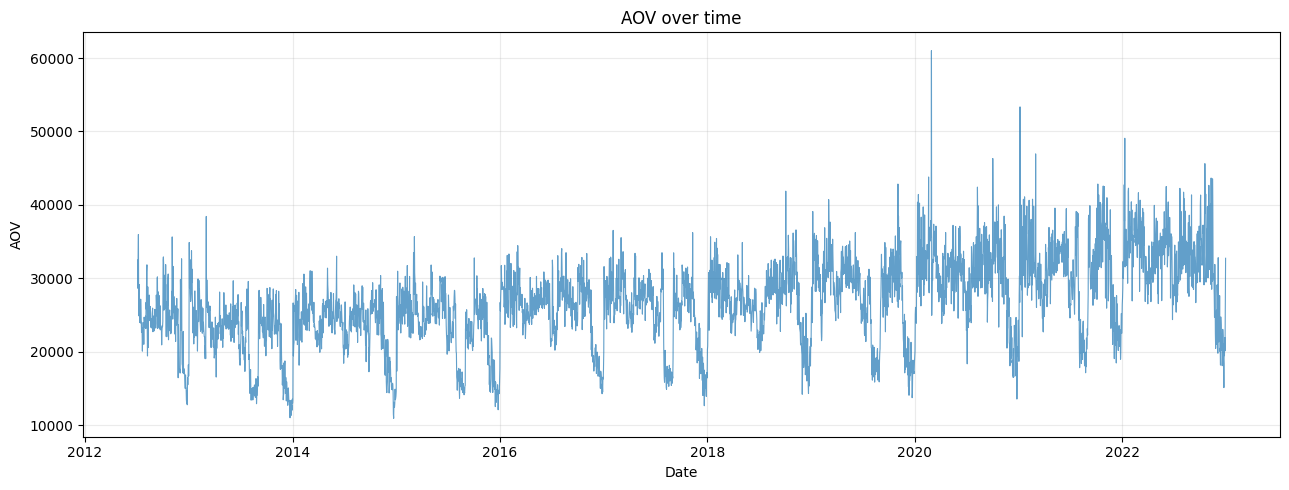

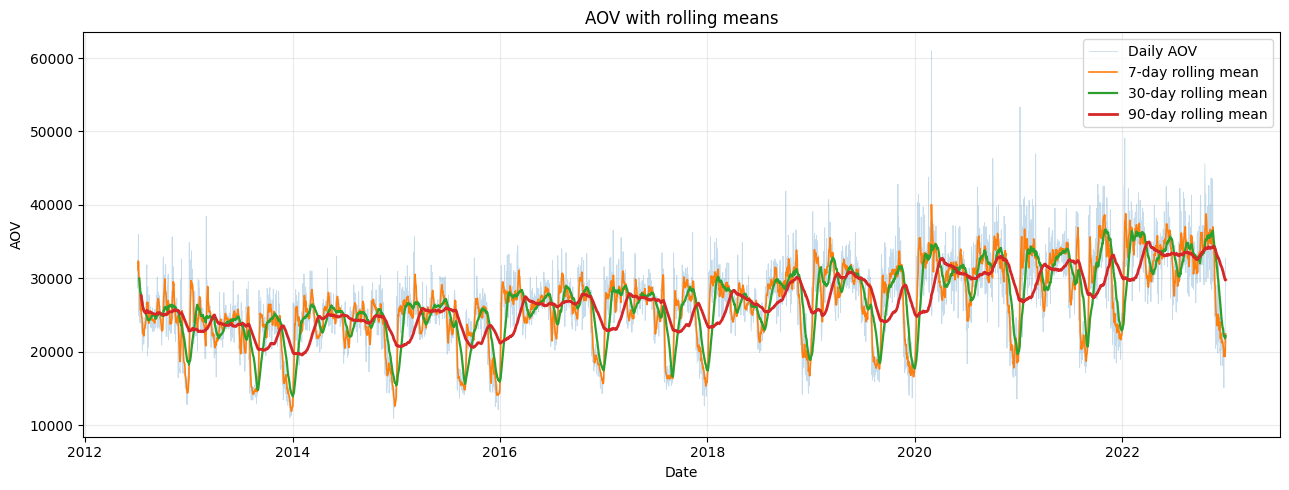

AOV trend: increasing based on 90-day rolling AOV (25,371.60 early vs 33,109.59 recent, 30.5%)


In [7]:
aov_trend_statement = "not available"

if not daily_ts.empty:
    daily_ts["AOV_roll_mean_7_descriptive"] = daily_ts["AOV"].rolling(7, min_periods=3).mean()
    daily_ts["AOV_roll_mean_30_descriptive"] = daily_ts["AOV"].rolling(30, min_periods=7).mean()
    daily_ts["AOV_roll_mean_90_descriptive"] = daily_ts["AOV"].rolling(90, min_periods=14).mean()
    daily_ts["order_count_roll_mean_30_descriptive"] = daily_ts["number_of_orders"].rolling(30, min_periods=7).mean()
    daily_ts["revenue_roll_mean_30_descriptive"] = daily_ts["revenue"].rolling(30, min_periods=7).mean()

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(daily_ts.index, daily_ts["AOV"], linewidth=0.8, alpha=0.7)
    ax.set_title("AOV over time")
    ax.set_xlabel("Date")
    ax.set_ylabel("AOV")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(daily_ts.index, daily_ts["AOV"], linewidth=0.6, alpha=0.25, label="Daily AOV")
    ax.plot(daily_ts.index, daily_ts["AOV_roll_mean_7_descriptive"], linewidth=1.2, label="7-day rolling mean")
    ax.plot(daily_ts.index, daily_ts["AOV_roll_mean_30_descriptive"], linewidth=1.6, label="30-day rolling mean")
    ax.plot(daily_ts.index, daily_ts["AOV_roll_mean_90_descriptive"], linewidth=2.0, label="90-day rolling mean")
    ax.set_title("AOV with rolling means")
    ax.set_xlabel("Date")
    ax.set_ylabel("AOV")
    ax.legend()
    plt.tight_layout()
    plt.show()

    first_window = daily_ts["AOV_roll_mean_90_descriptive"].dropna().head(90).mean()
    last_window = daily_ts["AOV_roll_mean_90_descriptive"].dropna().tail(90).mean()
    if np.isfinite(first_window) and np.isfinite(last_window) and first_window != 0:
        pct_change = (last_window - first_window) / first_window
        if abs(pct_change) < 0.03:
            aov_trend_statement = f"roughly stable based on 90-day rolling AOV ({first_window:,.2f} early vs {last_window:,.2f} recent)"
        elif pct_change > 0:
            aov_trend_statement = f"increasing based on 90-day rolling AOV ({first_window:,.2f} early vs {last_window:,.2f} recent, {pct_change:.1%})"
        else:
            aov_trend_statement = f"decreasing based on 90-day rolling AOV ({first_window:,.2f} early vs {last_window:,.2f} recent, {pct_change:.1%})"

    print(f"AOV trend: {aov_trend_statement}")
else:
    display_warning("AOV over time skipped because daily time series is unavailable.")

## 8. Revenue driver decomposition: order count vs AOV

Compare correlations and monthly movement to see whether revenue variation appears more aligned with order count or AOV. This is descriptive, not causal proof.

,relationship,correlation
0,daily revenue vs order count,0.9358
1,daily revenue vs AOV,-0.0693
2,daily order count vs AOV,-0.3542


,month,monthly_revenue,monthly_order_count,monthly_AOV,revenue_pct_change,order_count_pct_change,AOV_pct_change,decomposition_label
96,2020-07-01,"82,257,667.4600",2995,"27,464.9975",-0.1730,-0.0807,-0.1004,revenue decrease aligned more with AOV drop
97,2020-08-01,"109,937,100.9400",3309,"33,223.6630",0.3365,0.1048,0.2097,revenue increase aligned more with AOV
98,2020-09-01,"71,447,885.6400",2309,"30,943.2160",-0.3501,-0.3022,-0.0686,revenue decrease aligned more with order count...
99,2020-10-01,"61,657,119.3500",1853,"33,274.2144",-0.1370,-0.1975,0.0753,revenue decrease aligned more with order count...
100,2020-11-01,"41,418,160.2500",1438,"28,802.6149",-0.3283,-0.2240,-0.1344,revenue decrease aligned more with order count...
101,2020-12-01,"40,164,181.8800",2020,"19,883.2584",-0.0303,0.4047,-0.3097,revenue decrease aligned more with AOV drop
102,2021-01-01,"41,164,102.8600",1234,"33,358.2681",0.0249,-0.3891,0.6777,mixed or stable
103,2021-02-01,"59,188,476.9800",1776,"33,326.8451",0.4379,0.4392,-0.0009,revenue increase aligned more with order count
104,2021-03-01,"103,214,798.2000",3638,"28,371.3024",0.7438,1.0484,-0.1487,revenue increase aligned more with order count
105,2021-04-01,"122,119,359.3800",3948,"30,931.9553",0.1832,0.0852,0.0903,revenue increase aligned more with AOV


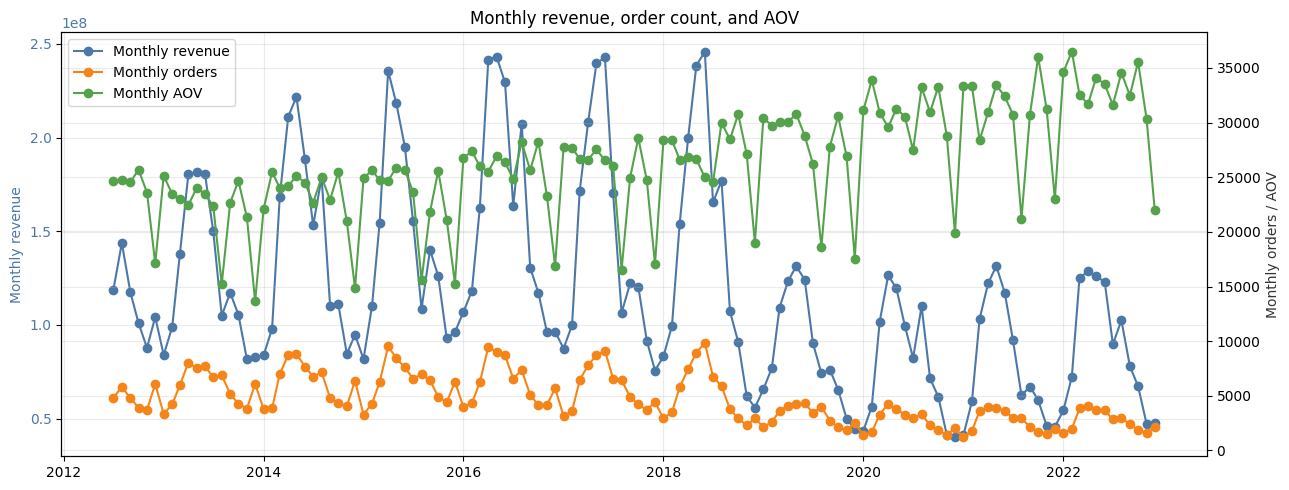

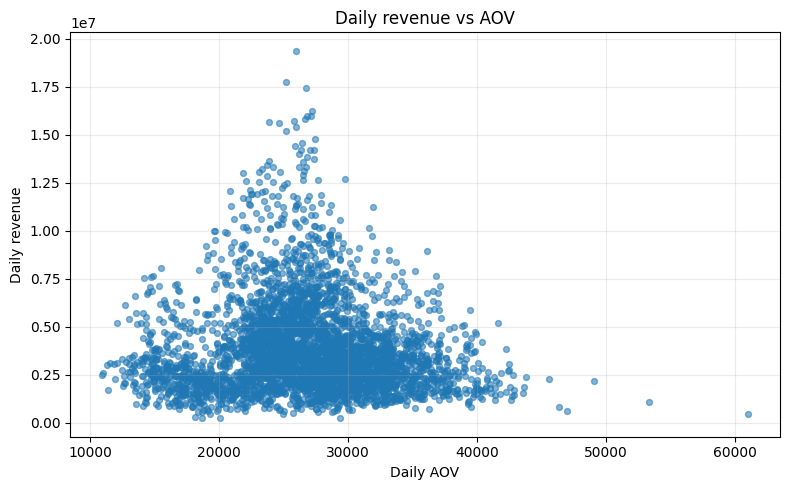

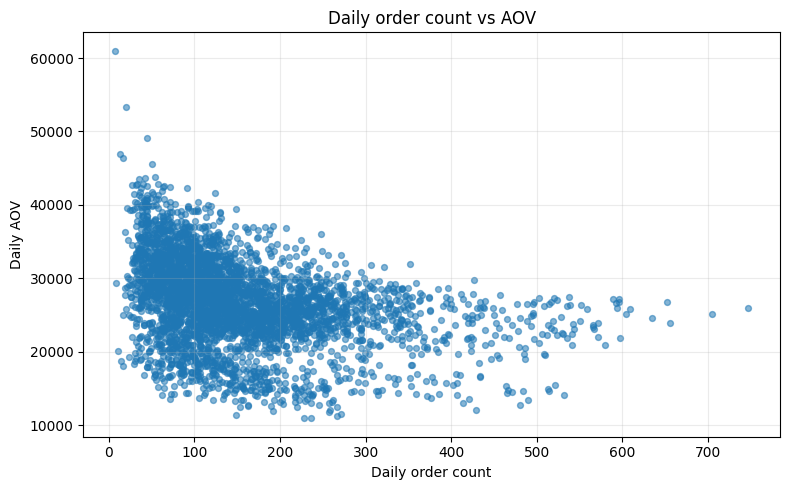

revenue variation appears more associated with order count (corr 0.936) than AOV (corr -0.069)


In [8]:
correlation_table = pd.DataFrame()
monthly_ts = pd.DataFrame()
revenue_driver_statement = "not available"
monthly_decomposition = pd.DataFrame()

if not daily_ts.empty:
    corr_data = daily_ts[["revenue", "number_of_orders", "AOV"]].replace([np.inf, -np.inf], np.nan)
    correlation_table = pd.DataFrame(
        [
            {"relationship": "daily revenue vs order count", "correlation": corr_data["revenue"].corr(corr_data["number_of_orders"])},
            {"relationship": "daily revenue vs AOV", "correlation": corr_data["revenue"].corr(corr_data["AOV"])},
            {"relationship": "daily order count vs AOV", "correlation": corr_data["number_of_orders"].corr(corr_data["AOV"])},
        ]
    )
    display(correlation_table)

    order_corr = correlation_table.loc[correlation_table["relationship"] == "daily revenue vs order count", "correlation"].iloc[0]
    aov_corr = correlation_table.loc[correlation_table["relationship"] == "daily revenue vs AOV", "correlation"].iloc[0]
    if abs(order_corr) > abs(aov_corr) + 0.05:
        revenue_driver_statement = f"revenue variation appears more associated with order count (corr {order_corr:.3f}) than AOV (corr {aov_corr:.3f})"
    elif abs(aov_corr) > abs(order_corr) + 0.05:
        revenue_driver_statement = f"revenue variation appears more associated with AOV (corr {aov_corr:.3f}) than order count (corr {order_corr:.3f})"
    else:
        revenue_driver_statement = f"revenue variation appears similarly associated with order count (corr {order_corr:.3f}) and AOV (corr {aov_corr:.3f})"

    monthly_ts = daily_ts.groupby("month").agg(
        monthly_revenue=("revenue", "sum"),
        monthly_order_count=("number_of_orders", "sum"),
    ).reset_index()
    monthly_ts["monthly_AOV"] = monthly_ts["monthly_revenue"] / monthly_ts["monthly_order_count"].replace(0, np.nan)
    monthly_ts["revenue_pct_change"] = monthly_ts["monthly_revenue"].pct_change()
    monthly_ts["order_count_pct_change"] = monthly_ts["monthly_order_count"].pct_change()
    monthly_ts["AOV_pct_change"] = monthly_ts["monthly_AOV"].pct_change()
    monthly_ts["decomposition_label"] = np.select(
        [
            (monthly_ts["revenue_pct_change"] > 0.03) & (monthly_ts["order_count_pct_change"] > monthly_ts["AOV_pct_change"]),
            (monthly_ts["revenue_pct_change"] > 0.03) & (monthly_ts["AOV_pct_change"] > monthly_ts["order_count_pct_change"]),
            (monthly_ts["revenue_pct_change"] < -0.03) & (monthly_ts["order_count_pct_change"] < monthly_ts["AOV_pct_change"]),
            (monthly_ts["revenue_pct_change"] < -0.03) & (monthly_ts["AOV_pct_change"] < monthly_ts["order_count_pct_change"]),
        ],
        [
            "revenue increase aligned more with order count",
            "revenue increase aligned more with AOV",
            "revenue decrease aligned more with order count drop",
            "revenue decrease aligned more with AOV drop",
        ],
        default="mixed or stable",
    )
    display(monthly_ts.tail(30))

    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax1.plot(monthly_ts["month"], monthly_ts["monthly_revenue"], color="#4C78A8", marker="o", label="Monthly revenue")
    ax1.set_ylabel("Monthly revenue", color="#4C78A8")
    ax1.tick_params(axis="y", labelcolor="#4C78A8")
    ax2 = ax1.twinx()
    ax2.plot(monthly_ts["month"], monthly_ts["monthly_order_count"], color="#F58518", marker="o", label="Monthly orders")
    ax2.plot(monthly_ts["month"], monthly_ts["monthly_AOV"], color="#54A24B", marker="o", label="Monthly AOV")
    ax2.set_ylabel("Monthly orders / AOV", color="#333333")
    ax1.set_title("Monthly revenue, order count, and AOV")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(daily_ts["AOV"], daily_ts["revenue"], alpha=0.55, s=18)
    ax.set_title("Daily revenue vs AOV")
    ax.set_xlabel("Daily AOV")
    ax.set_ylabel("Daily revenue")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(daily_ts["number_of_orders"], daily_ts["AOV"], alpha=0.55, s=18)
    ax.set_title("Daily order count vs AOV")
    ax.set_xlabel("Daily order count")
    ax.set_ylabel("Daily AOV")
    plt.tight_layout()
    plt.show()

    print(revenue_driver_statement)
else:
    display_warning("Revenue driver decomposition skipped because daily time series is unavailable.")

## 9. AOV by month

AOV by month of year is summarized with revenue and order count to inspect seasonal AOV patterns and compare them with volume seasonality.

,month_of_year,revenue,order_count,average_daily_AOV,median_daily_AOV,average_daily_order_count,aggregate_AOV,order_count_rank,AOV_rank
0,1,"731,255,885.0700",26832,"28,944.2009","28,470.9521",86.5548,"27,253.1263",12.0000,4.0000
1,2,"889,559,750.8900",31802,"29,316.8768","28,533.8088",112.7730,"27,971.8178",11.0000,2.0000
2,3,"1,387,643,532.6100",52109,"28,275.6112","27,851.5151",168.0935,"26,629.6327",6.0000,6.0000
3,4,"1,777,338,373.5200",67437,"27,293.3369","26,596.4944",224.7900,"26,355.5374",1.0000,7.0000
4,5,"1,850,463,689.2800",67198,"28,691.2883","27,834.1269",216.7677,"27,537.4816",2.0000,3.0000
5,6,"1,745,275,443.7600",65508,"28,163.6945","27,638.9857",218.3600,"26,642.1726",3.0000,5.0000
6,7,"1,430,010,559.3400",56982,"26,140.9496","25,536.9452",168.5858,"25,095.8295",5.0000,9.0000
7,8,"1,375,575,419.2100",59711,"23,955.2911","24,104.3465",175.1056,"23,037.2196",4.0000,11.0000
8,9,"1,137,074,968.6300",44544,"27,041.9795","26,632.4709",134.9818,"25,527.0063",8.0000,8.0000
9,10,"1,025,853,104.3100",36336,"29,768.3705","29,175.4227",106.5572,"28,232.4170",9.0000,1.0000


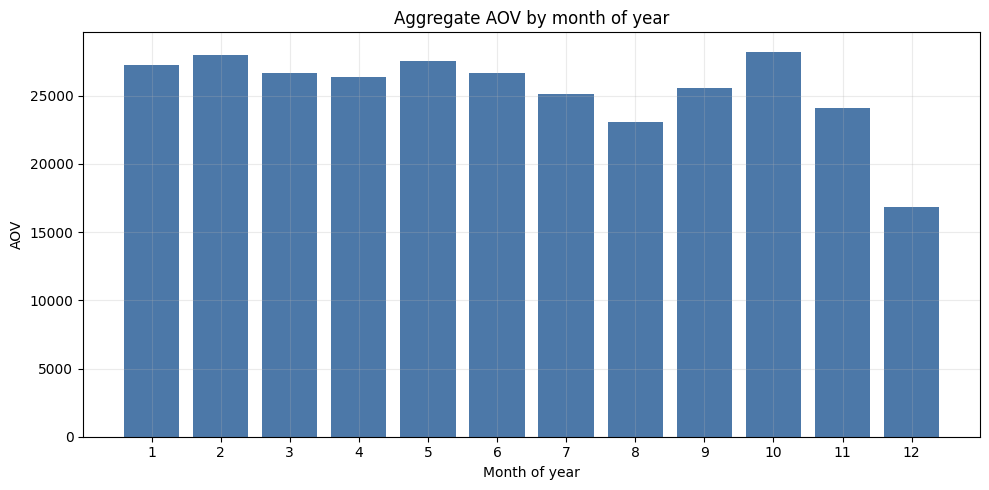

In [9]:
month_aov = pd.DataFrame()

if not daily_ts.empty:
    month_aov = daily_ts.groupby("month_of_year").agg(
        revenue=("revenue", "sum"),
        order_count=("number_of_orders", "sum"),
        average_daily_AOV=("AOV", "mean"),
        median_daily_AOV=("AOV", "median"),
        average_daily_order_count=("number_of_orders", "mean"),
    ).reset_index()
    month_aov["aggregate_AOV"] = month_aov["revenue"] / month_aov["order_count"].replace(0, np.nan)
    month_aov["order_count_rank"] = month_aov["order_count"].rank(ascending=False)
    month_aov["AOV_rank"] = month_aov["aggregate_AOV"].rank(ascending=False)
    display(month_aov)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(month_aov["month_of_year"].astype(str), month_aov["aggregate_AOV"], color="#4C78A8")
    ax.set_title("Aggregate AOV by month of year")
    ax.set_xlabel("Month of year")
    ax.set_ylabel("AOV")
    plt.tight_layout()
    plt.show()
else:
    display_warning("AOV by month skipped because daily time series is unavailable.")

## 10. AOV by acquisition channel

Customer acquisition channel is joined when available. If unavailable, order source is used as a proxy channel and labeled through the detected column.

,acquisition_channel,orders,revenue,AOV,revenue_share,volume_share,small_sample_flag
5,social_media,117478,"3,001,527,075.2100","25,549.6951",0.2012,0.2000,False
2,organic_search,176528,"4,487,706,741.8500","25,422.0676",0.3009,0.3005,False
3,paid_search,117005,"2,965,420,681.3200","25,344.3928",0.1988,0.1992,False
4,referral,58555,"1,482,467,579.2000","25,317.5233",0.0994,0.0997,False
1,email_campaign,70606,"1,784,844,775.3300","25,278.9391",0.1197,0.1202,False
0,direct,47311,"1,192,618,726.4300","25,208.0642",0.0800,0.0805,False


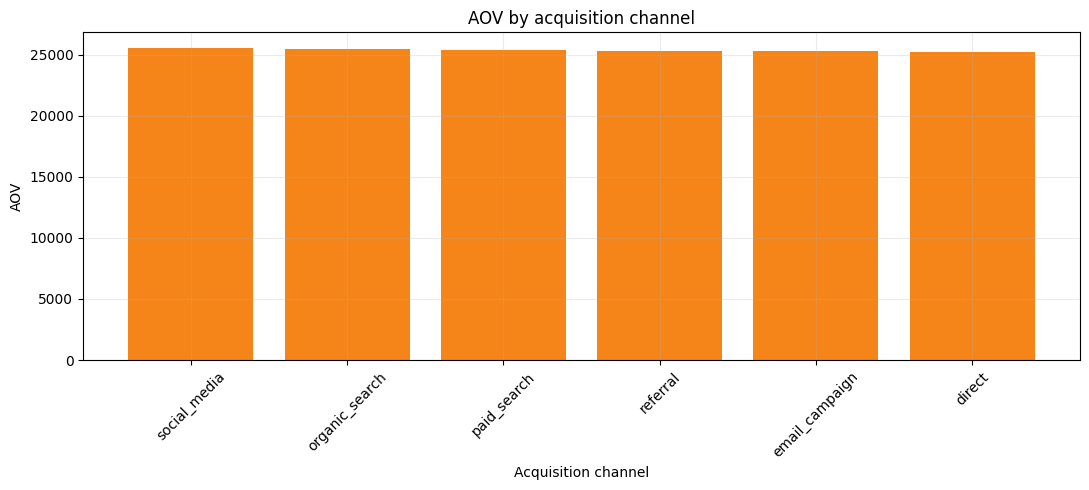

In [10]:
channel_aov = pd.DataFrame()

if not order_level.empty and "acquisition_channel" in order_level.columns:
    channel_aov = order_level.loc[~order_level["excluded_status_flag"].fillna(False)].groupby("acquisition_channel").agg(
        orders=("_order_id", "nunique"),
        revenue=("order_revenue", "sum"),
    ).reset_index()
    channel_aov["AOV"] = channel_aov["revenue"] / channel_aov["orders"].replace(0, np.nan)
    channel_aov["revenue_share"] = channel_aov["revenue"] / channel_aov["revenue"].sum()
    channel_aov["volume_share"] = channel_aov["orders"] / channel_aov["orders"].sum()
    channel_aov["small_sample_flag"] = channel_aov["orders"] < max(30, channel_aov["orders"].median() * 0.1)
    channel_aov = channel_aov.sort_values("AOV", ascending=False)
    display(channel_aov)

    fig, ax = plt.subplots(figsize=(11, 5))
    plot_df = channel_aov.sort_values("AOV", ascending=False)
    ax.bar(plot_df["acquisition_channel"].astype(str), plot_df["AOV"], color="#F58518")
    ax.set_title("AOV by acquisition channel")
    ax.set_xlabel("Acquisition channel")
    ax.set_ylabel("AOV")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    display_warning("AOV by acquisition channel skipped because channel data is unavailable.")

## 11. AOV by payment method

Payment method groups are compared by order count, revenue, and AOV. This is behavioral association only, not a causal claim about payment method.

,payment_method,orders,revenue,AOV,revenue_share,volume_share,small_sample_flag
4,paypal,89201,"2,278,600,034.1300","25,544.5571",0.1528,0.1518,False
2,cod,81213,"2,064,100,604.2800","25,415.8891",0.1384,0.1382,False
3,credit_card,327900,"8,315,447,530.3400","25,359.7058",0.5575,0.5581,False
0,apple_pay,59573,"1,507,847,041.9000","25,310.9134",0.1011,0.1014,False
1,bank_transfer,29596,"748,590,368.6900","25,293.6332",0.0502,0.0504,False


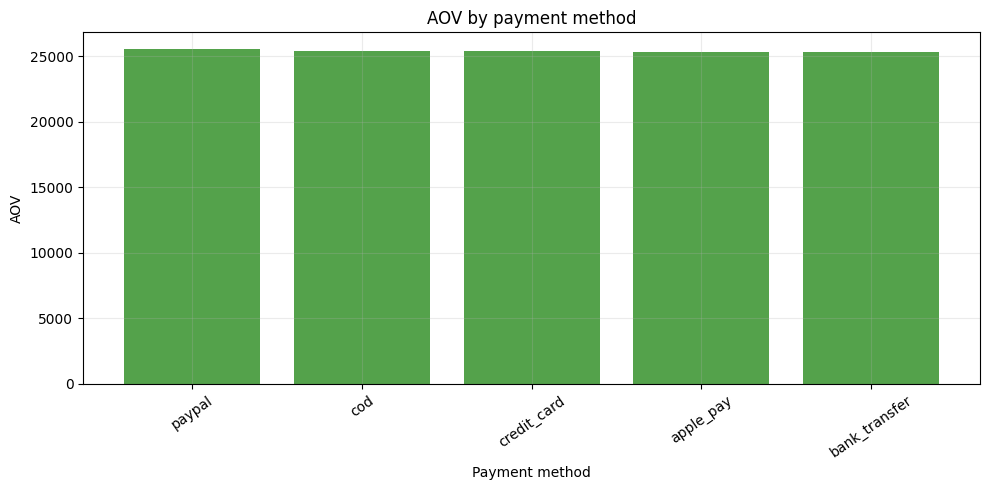

In [11]:
payment_aov = pd.DataFrame()

if not order_level.empty and "payment_method" in order_level.columns:
    payment_aov = order_level.loc[~order_level["excluded_status_flag"].fillna(False)].groupby("payment_method").agg(
        orders=("_order_id", "nunique"),
        revenue=("order_revenue", "sum"),
    ).reset_index()
    payment_aov["AOV"] = payment_aov["revenue"] / payment_aov["orders"].replace(0, np.nan)
    payment_aov["revenue_share"] = payment_aov["revenue"] / payment_aov["revenue"].sum()
    payment_aov["volume_share"] = payment_aov["orders"] / payment_aov["orders"].sum()
    payment_aov["small_sample_flag"] = payment_aov["orders"] < max(30, payment_aov["orders"].median() * 0.1)
    payment_aov = payment_aov.sort_values("AOV", ascending=False)
    display(payment_aov)

    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = payment_aov.sort_values("AOV", ascending=False)
    ax.bar(plot_df["payment_method"].astype(str), plot_df["AOV"], color="#54A24B")
    ax.set_title("AOV by payment method")
    ax.set_xlabel("Payment method")
    ax.set_ylabel("AOV")
    ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.show()
else:
    display_warning("AOV by payment method skipped because payment method data is unavailable.")

## 12. AOV by category

Orders can contain multiple categories, so this section uses attributed category revenue divided by the number of unique orders containing that category. This is category-associated order value, not full order AOV for single-category-only baskets.

,category,orders,item_lines,category_revenue,total_quantity,matched_product_rows,category_order_value,average_item_line_value,average_unit_value,revenue_share
3,Streetwear,389543,393533,"13,131,346,352.6200",1768826,393533,"33,709.6196","33,367.8404","7,423.7638",0.7992
0,Casual,23600,23991,"460,648,383.3500",107469,23991,"19,518.9993","19,200.8830","4,286.3373",0.0280
2,Outdoor,200454,259986,"2,494,882,754.2000",1170000,259986,"12,446.1610","9,596.2196","2,132.3784",0.1518
1,GenZ,37054,37159,"343,599,095.3600",166848,37159,"9,272.9286","9,246.7261","2,059.3540",0.0209


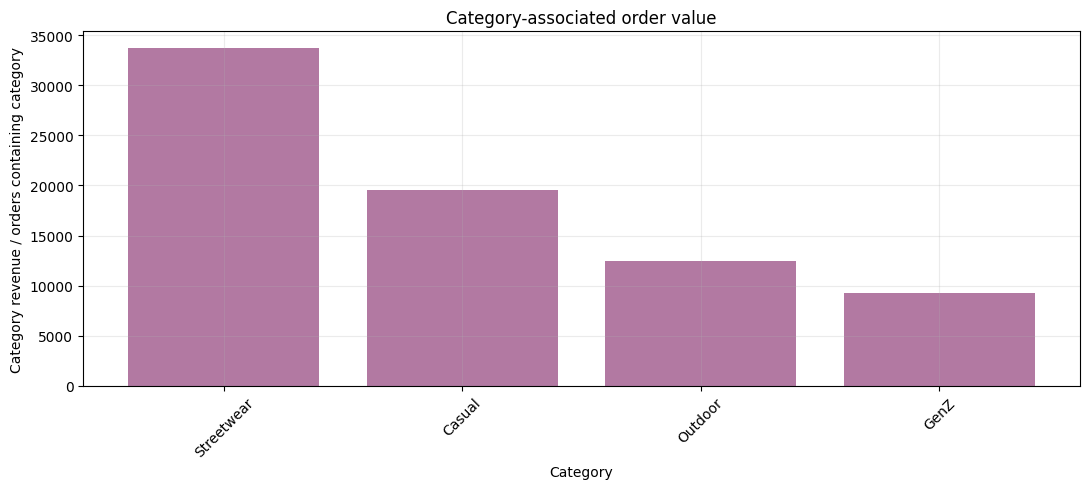

In [12]:
category_aov = pd.DataFrame()

if not items_work.empty and products is not None and item_product_col is not None and product_product_col is not None and category_col is not None:
    products_work = products.copy()
    products_work["_product_id"] = products_work[product_product_col].astype(str)
    category_dim = products_work[["_product_id", category_col]].drop_duplicates("_product_id")
    category_items = items_work.merge(category_dim, on="_product_id", how="left", indicator="_product_join")
    category_items[category_col] = category_items[category_col].fillna("Unknown").astype(str)
    category_aov = category_items.groupby(category_col).agg(
        orders=("_order_id", "nunique"),
        item_lines=("item_revenue", "size"),
        category_revenue=("item_revenue", "sum"),
        total_quantity=("item_quantity", "sum"),
        matched_product_rows=("_product_join", lambda s: (s == "both").sum()),
    ).reset_index()
    category_aov["category_order_value"] = category_aov["category_revenue"] / category_aov["orders"].replace(0, np.nan)
    category_aov["average_item_line_value"] = category_aov["category_revenue"] / category_aov["item_lines"].replace(0, np.nan)
    category_aov["average_unit_value"] = category_aov["category_revenue"] / category_aov["total_quantity"].replace(0, np.nan)
    category_aov["revenue_share"] = category_aov["category_revenue"] / category_aov["category_revenue"].sum()
    category_aov = category_aov.sort_values("category_order_value", ascending=False)
    display(category_aov)

    fig, ax = plt.subplots(figsize=(11, 5))
    plot_df = category_aov.sort_values("category_order_value", ascending=False).head(20)
    ax.bar(plot_df[category_col].astype(str), plot_df["category_order_value"], color="#B279A2")
    ax.set_title("Category-associated order value")
    ax.set_xlabel("Category")
    ax.set_ylabel("Category revenue / orders containing category")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    display_warning("AOV by category skipped because product/category join fields are unavailable.")

## 13. AOV by promotion/campaign

Promotion/campaign exposure is approximated internally from order-item promotion/discount fields and promotion date windows when available. This compares AOV during flagged periods versus unflagged periods without claiming causality.

,label,orders,revenue,AOV,order_share,revenue_share,item_promo_orders,calendar_window_orders
0,not promotion/campaign flagged,315276,"8,733,183,207.6200","27,700.1206",0.5367,0.5855,0,0
1,promotion/campaign flagged,272207,"6,181,402,371.7200","22,708.4622",0.4633,0.4145,225359,272207


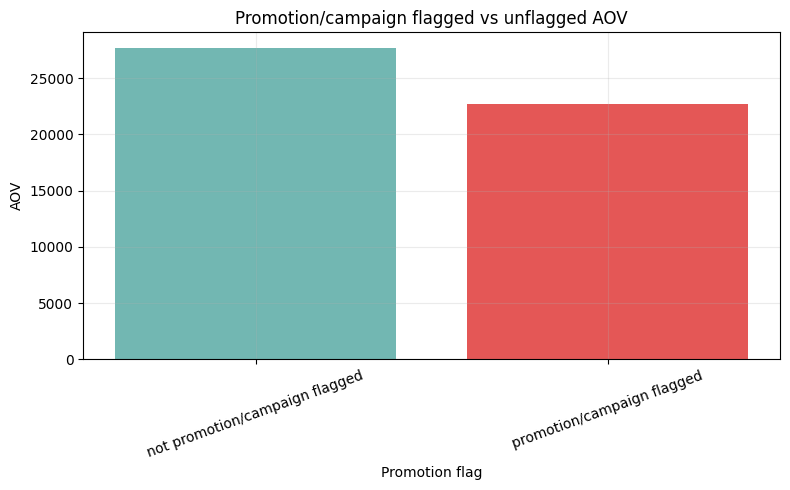

In [13]:
promo_aov = pd.DataFrame()

if not order_level.empty and "is_promo_order" in order_level.columns:
    promo_aov = order_level.loc[~order_level["excluded_status_flag"].fillna(False)].groupby("is_promo_order").agg(
        orders=("_order_id", "nunique"),
        revenue=("order_revenue", "sum"),
        item_promo_orders=("has_item_promo", "sum"),
        calendar_window_orders=("in_promotion_calendar_window", "sum"),
    ).reset_index()
    promo_aov["label"] = np.where(promo_aov["is_promo_order"], "promotion/campaign flagged", "not promotion/campaign flagged")
    promo_aov["AOV"] = promo_aov["revenue"] / promo_aov["orders"].replace(0, np.nan)
    promo_aov["order_share"] = promo_aov["orders"] / promo_aov["orders"].sum()
    promo_aov["revenue_share"] = promo_aov["revenue"] / promo_aov["revenue"].sum()
    display(promo_aov[["label", "orders", "revenue", "AOV", "order_share", "revenue_share", "item_promo_orders", "calendar_window_orders"]])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(promo_aov["label"], promo_aov["AOV"], color=["#72B7B2", "#E45756"])
    ax.set_title("Promotion/campaign flagged vs unflagged AOV")
    ax.set_xlabel("Promotion flag")
    ax.set_ylabel("AOV")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()
else:
    display_warning("Promotion/campaign AOV skipped because promotion indicators are unavailable.")

## 14. AOV anomaly checks

Detect unusually high and low daily AOV values and show whether extreme AOV days are driven by very few orders.

In [14]:
aov_anomalies = pd.DataFrame()
high_aov_days = pd.DataFrame()
low_aov_days = pd.DataFrame()
high_aov_orders = pd.DataFrame()
low_aov_orders = pd.DataFrame()
anomaly_warning = "not available"

if not daily_ts.empty:
    order_days = daily_ts[daily_ts["number_of_orders"] > 0].copy()
    aov_mean = order_days["AOV"].mean()
    aov_std = order_days["AOV"].std(ddof=0)
    q1 = order_days["AOV"].quantile(0.25)
    q3 = order_days["AOV"].quantile(0.75)
    iqr = q3 - q1
    high_threshold = max(order_days["AOV"].quantile(0.99), q3 + 1.5 * iqr)
    low_threshold = min(order_days["AOV"].quantile(0.01), q1 - 1.5 * iqr)
    anomaly_df = order_days[["revenue", "number_of_orders", "AOV"]].copy()
    anomaly_df["AOV_zscore"] = (anomaly_df["AOV"] - aov_mean) / aov_std if aov_std else np.nan
    anomaly_df["is_high_AOV_day"] = (anomaly_df["AOV"] >= high_threshold) | (anomaly_df["AOV_zscore"] >= 3)
    anomaly_df["is_low_AOV_day"] = (anomaly_df["AOV"] <= low_threshold) | (anomaly_df["AOV_zscore"] <= -3)
    aov_anomalies = anomaly_df[anomaly_df["is_high_AOV_day"] | anomaly_df["is_low_AOV_day"]].reset_index()
    high_aov_days = aov_anomalies[aov_anomalies["is_high_AOV_day"]].sort_values("AOV", ascending=False)
    low_aov_days = aov_anomalies[aov_anomalies["is_low_AOV_day"]].sort_values("AOV", ascending=True)

    print("High-AOV days:")
    display(high_aov_days.head(15))
    print("Low-AOV days:")
    display(low_aov_days.head(15))

    high_aov_orders = order_level.loc[~order_level["excluded_status_flag"].fillna(False)].sort_values("order_revenue", ascending=False).head(20)
    low_aov_orders = order_level.loc[(~order_level["excluded_status_flag"].fillna(False)) & (order_level["order_revenue"].notna())].sort_values("order_revenue", ascending=True).head(20)
    print("Highest-value individual orders:")
    display(high_aov_orders[["_order_id", "order_date", "order_revenue", "payment_method", "acquisition_channel", "is_promo_order"]].head(20))
    print("Lowest-value individual orders:")
    display(low_aov_orders[["_order_id", "order_date", "order_revenue", "payment_method", "acquisition_channel", "is_promo_order"]].head(20))

    low_volume_extremes = high_aov_days[high_aov_days["number_of_orders"] <= order_days["number_of_orders"].quantile(0.10)]
    if not low_volume_extremes.empty:
        anomaly_warning = f"{len(low_volume_extremes)} high-AOV days are in the bottom 10% of order volume, so daily AOV extremes may be low-volume artifacts"
    else:
        anomaly_warning = "high-AOV days are not concentrated in the lowest-volume days by the configured rule"
    print(f"AOV anomaly warning: {anomaly_warning}")
else:
    display_warning("AOV anomaly checks skipped because daily time series is unavailable.")

High-AOV days:


,date,revenue,number_of_orders,AOV,AOV_zscore,is_high_AOV_day,is_low_AOV_day
20,2020-02-29,"426,980.1200",7,"60,997.1600",5.9106,True,False
23,2021-01-06,"1,066,921.6900",20,"53,346.0845",4.5906,True,False
33,2022-01-10,"2,159,146.9400",44,"49,071.5214",3.8531,True,False
25,2021-03-02,"610,279.3900",13,"46,944.5685",3.4861,True,False
22,2020-10-02,"787,410.3800",17,"46,318.2576",3.3781,True,False
42,2022-10-19,"2,280,930.6700",50,"45,618.6134",3.2574,True,False
19,2020-02-19,"2,365,076.1700",54,"43,797.7069",2.9432,True,False
46,2022-11-10,"1,833,613.7200",42,"43,657.4695",2.9190,True,False
47,2022-11-15,"1,524,158.2600",35,"43,547.3789",2.9000,True,False
17,2019-11-03,"1,413,702.1400",33,"42,839.4588",2.7779,True,False


Low-AOV days:


,date,revenue,number_of_orders,AOV,AOV_zscore,is_high_AOV_day,is_low_AOV_day
10,2014-12-23,"2,491,297.3700",228,"10,926.7429",-2.7281,False,True
2,2013-12-23,"2,597,857.9500",236,"11,007.8727",-2.7141,False,True
1,2013-12-22,"3,009,544.9100",267,"11,271.7038",-2.6686,False,True
5,2013-12-27,"1,677,839.9900",148,"11,336.7567",-2.6574,False,True
9,2014-12-22,"3,112,717.2000",271,"11,486.0413",-2.6316,False,True
6,2013-12-28,"3,040,690.6700",257,"11,831.4812",-2.5720,False,True
3,2013-12-24,"2,282,383.2400",192,"11,887.4127",-2.5624,False,True
8,2013-12-30,"5,163,846.6800",429,"12,036.9386",-2.5366,False,True
14,2015-12-26,"3,120,332.7100",258,"12,094.3128",-2.5267,False,True
12,2014-12-26,"2,738,636.6900",220,"12,448.3486",-2.4656,False,True


Highest-value individual orders:


,_order_id,order_date,order_revenue,payment_method,acquisition_channel,is_promo_order
500803,645732,2019-01-12,"331,570.4000",credit_card,organic_search,False
489769,631538,2018-09-24,"302,124.0800",apple_pay,social_media,True
488354,629691,2018-09-14,"299,060.2400",credit_card,direct,True
469234,605128,2018-06-22,"250,034.8800",cod,paid_search,False
436727,563097,2018-02-24,"246,463.2000",cod,referral,False
628947,811089,2022-06-11,"221,621.3000",bank_transfer,social_media,False
553460,713659,2020-04-29,"217,184.3800",apple_pay,email_campaign,False
613812,791551,2022-02-22,"214,492.5800",credit_card,organic_search,False
452042,582948,2018-05-02,"206,329.7600",credit_card,organic_search,False
480145,619091,2018-08-02,"205,516.4000",credit_card,organic_search,False


Lowest-value individual orders:


,_order_id,order_date,order_revenue,payment_method,acquisition_channel,is_promo_order
583768,752798,2021-03-31,442.8900,apple_pay,organic_search,True
108263,139713,2014-01-02,535.2500,credit_card,social_media,True
186582,240678,2014-12-25,535.4300,paypal,organic_search,True
353429,455819,2016-12-27,536.1800,credit_card,referral,True
349551,450847,2016-12-12,536.3400,cod,email_campaign,True
106975,138099,2013-12-27,540.1500,bank_transfer,organic_search,True
322032,415379,2016-07-21,540.2400,credit_card,email_campaign,True
180760,233214,2014-11-24,540.3800,credit_card,paid_search,True
352396,454505,2016-12-27,542.5000,credit_card,direct,True
188821,243609,2015-01-01,543.5000,apple_pay,organic_search,True


AOV anomaly warning: 24 high-AOV days are in the bottom 10% of order volume, so daily AOV extremes may be low-volume artifacts


## 15. Leakage-safe AOV forecast feature preview

Candidate forecast features use shifted AOV, order count, and revenue. Date `t` features use only dates before `t`.

In [15]:
aov_features = pd.DataFrame()

if not daily_ts.empty:
    aov_features = pd.DataFrame(index=daily_ts.index)
    aov_features["revenue"] = daily_ts["revenue"]
    aov_features["number_of_orders"] = daily_ts["number_of_orders"]
    aov_features["AOV"] = daily_ts["AOV"]
    shifted_aov = daily_ts["AOV"].shift(1)
    shifted_orders = daily_ts["number_of_orders"].shift(1)
    shifted_revenue = daily_ts["revenue"].shift(1)
    aov_features["aov_lag_1"] = daily_ts["AOV"].shift(1)
    aov_features["aov_lag_7"] = daily_ts["AOV"].shift(7)
    aov_features["aov_lag_30"] = daily_ts["AOV"].shift(30)
    aov_features["aov_roll_mean_7"] = shifted_aov.rolling(7, min_periods=3).mean()
    aov_features["aov_roll_mean_30"] = shifted_aov.rolling(30, min_periods=7).mean()
    aov_features["aov_roll_mean_90"] = shifted_aov.rolling(90, min_periods=14).mean()
    aov_features["aov_roll_std_30"] = shifted_aov.rolling(30, min_periods=7).std()
    aov_features["order_count_lag_1"] = daily_ts["number_of_orders"].shift(1)
    aov_features["order_count_roll_mean_30"] = shifted_orders.rolling(30, min_periods=7).mean()
    aov_features["revenue_lag_1"] = shifted_revenue
    aov_features = aov_features.reset_index().rename(columns={"index": "date"})
    print("Feature preview. All lag and rolling features are shifted before use to avoid current-day leakage.")
    display(aov_features.head(40))
else:
    display_warning("Leakage-safe AOV feature preview skipped because daily time series is unavailable.")

Feature preview. All lag and rolling features are shifted before use to avoid current-day leakage.


,date,revenue,number_of_orders,AOV,aov_lag_1,aov_lag_7,aov_lag_30,aov_roll_mean_7,aov_roll_mean_30,aov_roll_mean_90,aov_roll_std_30,order_count_lag_1,order_count_roll_mean_30,revenue_lag_1
0,2012-07-04,"4,968,762.1200",153,"32,475.5694",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,"2,520,721.7900",88,"28,644.5658","32,475.5694",NaN,NaN,NaN,NaN,NaN,NaN,153.0000,NaN,"4,968,762.1200"
2,2012-07-06,"2,646,490.5500",82,"32,274.2750","28,644.5658",NaN,NaN,NaN,NaN,NaN,NaN,88.0000,NaN,"2,520,721.7900"
3,2012-07-07,"2,337,896.9600",65,"35,967.6455","32,274.2750",NaN,NaN,"31,131.4701",NaN,NaN,NaN,82.0000,NaN,"2,646,490.5500"
4,2012-07-08,"2,199,273.3700",83,"26,497.2695","35,967.6455",NaN,NaN,"32,340.5139",NaN,NaN,NaN,65.0000,NaN,"2,337,896.9600"
5,2012-07-09,"2,909,927.1800",117,"24,871.1725","26,497.2695",NaN,NaN,"31,171.8651",NaN,NaN,NaN,83.0000,NaN,"2,199,273.3700"
6,2012-07-10,"4,809,139.3800",165,"29,146.2993","24,871.1725",NaN,NaN,"30,121.7496",NaN,NaN,NaN,117.0000,NaN,"2,909,927.1800"
7,2012-07-11,"5,279,686.0500",205,"25,754.5661","29,146.2993","32,475.5694",NaN,"29,982.3996","29,982.3996",NaN,"3,830.8266",165.0000,107.5714,"4,809,139.3800"
8,2012-07-12,"5,418,901.4000",226,"23,977.4398","25,754.5661","28,644.5658",NaN,"29,022.2562","29,453.9204",NaN,"3,848.7781",205.0000,119.7500,"5,279,686.0500"
9,2012-07-13,"4,767,890.6400",183,"26,054.0472","23,977.4398","32,274.2750",NaN,"28,355.5240","28,845.4225",NaN,"4,036.5682",226.0000,131.5556,"5,418,901.4000"


## 16. Key observations and warnings

The final summary reports overall AOV, AOV trend, revenue association with order count versus AOV, high/low AOV cuts, anomaly warnings, and leakage-safe forecast feature recommendations.

In [16]:
print("Concise insight summary")
print("=" * 80)

print(f"Overall AOV: {overall_aov:,.2f}" if np.isfinite(overall_aov) else "Overall AOV: not available.")
print(f"AOV trend over time: {aov_trend_statement}.")
print(f"Revenue driver decomposition: {revenue_driver_statement}.")

if not month_aov.empty:
    high_month = month_aov.sort_values("aggregate_AOV", ascending=False).iloc[0]
    low_month = month_aov.sort_values("aggregate_AOV", ascending=True).iloc[0]
    print(f"Highest AOV month of year: {int(high_month.month_of_year)} ({high_month.aggregate_AOV:,.2f}).")
    print(f"Lowest AOV month of year: {int(low_month.month_of_year)} ({low_month.aggregate_AOV:,.2f}).")
else:
    print("Highest/lowest AOV month of year: not available.")

if not channel_aov.empty:
    high_channel = channel_aov.sort_values("AOV", ascending=False).head(3)
    low_channel = channel_aov.sort_values("AOV", ascending=True).head(3)
    print("Acquisition channels with high AOV: " + "; ".join(f"{row.acquisition_channel} ({row.AOV:,.2f}, {row.orders:,.0f} orders)" for row in high_channel.itertuples(index=False)) + ".")
    print("Acquisition channels with low AOV: " + "; ".join(f"{row.acquisition_channel} ({row.AOV:,.2f}, {row.orders:,.0f} orders)" for row in low_channel.itertuples(index=False)) + ".")
else:
    print("Acquisition-channel AOV: not available.")

if not payment_aov.empty:
    high_payment = payment_aov.sort_values("AOV", ascending=False).head(3)
    low_payment = payment_aov.sort_values("AOV", ascending=True).head(3)
    print("Payment methods with high AOV: " + "; ".join(f"{row.payment_method} ({row.AOV:,.2f}, {row.orders:,.0f} orders)" for row in high_payment.itertuples(index=False)) + ".")
    print("Payment methods with low AOV: " + "; ".join(f"{row.payment_method} ({row.AOV:,.2f}, {row.orders:,.0f} orders)" for row in low_payment.itertuples(index=False)) + ".")
else:
    print("Payment-method AOV: not available.")

if not category_aov.empty:
    category_label_col = category_col
    high_category = category_aov.sort_values("category_order_value", ascending=False).head(3)
    low_category = category_aov.sort_values("category_order_value", ascending=True).head(3)
    print("Categories with high category-associated order value: " + "; ".join(f"{getattr(row, category_label_col)} ({row.category_order_value:,.2f})" for row in high_category.itertuples(index=False)) + ".")
    print("Categories with low category-associated order value: " + "; ".join(f"{getattr(row, category_label_col)} ({row.category_order_value:,.2f})" for row in low_category.itertuples(index=False)) + ".")
else:
    print("Category-associated AOV/order value: not available.")

if not promo_aov.empty and len(promo_aov) >= 2:
    promo_true = promo_aov.loc[promo_aov["is_promo_order"] == True]
    promo_false = promo_aov.loc[promo_aov["is_promo_order"] == False]
    if not promo_true.empty and not promo_false.empty:
        diff = promo_true["AOV"].iloc[0] - promo_false["AOV"].iloc[0]
        pct = diff / promo_false["AOV"].iloc[0] if promo_false["AOV"].iloc[0] else np.nan
        print(f"Promotion/campaign periods appear to have AOV difference of {diff:,.2f} ({pct:.1%}) versus unflagged orders. This is an association, not a causal estimate.")
else:
    print("Promotion/campaign AOV comparison: not available.")

print(f"AOV anomaly warnings: {anomaly_warning}.")

if not high_aov_days.empty:
    text = "; ".join(f"{row.date.date()} (AOV {row.AOV:,.2f}, orders {row.number_of_orders:,.0f})" for row in high_aov_days.head(5).itertuples(index=False))
    print(f"Highest flagged AOV days: {text}.")
if not low_aov_days.empty:
    text = "; ".join(f"{row.date.date()} (AOV {row.AOV:,.2f}, orders {row.number_of_orders:,.0f})" for row in low_aov_days.head(5).itertuples(index=False))
    print(f"Lowest flagged AOV days: {text}.")

recommended_features = [
    "aov_lag_1",
    "aov_lag_7",
    "aov_lag_30",
    "aov_roll_mean_7",
    "aov_roll_mean_30",
    "aov_roll_mean_90",
    "aov_roll_std_30",
    "order_count_lag_1",
    "order_count_roll_mean_30",
    "revenue_lag_1",
]
print("Recommended leakage-safe AOV forecast features: " + ", ".join(recommended_features) + ".")
print("Forecasting note: AOV can be forecasted separately and combined with forecasted order count as forecast_revenue = forecast_order_count x forecast_AOV.")

quality_warnings = []
if quality:
    if quality.get("orders_with_missing_revenue", 0):
        quality_warnings.append(f"{quality['orders_with_missing_revenue']:,} orders with missing revenue")
    if quality.get("orders_with_zero_revenue", 0):
        quality_warnings.append(f"{quality['orders_with_zero_revenue']:,} zero-revenue orders")
    if quality.get("orders_with_negative_revenue", 0):
        quality_warnings.append(f"{quality['orders_with_negative_revenue']:,} negative-revenue orders")
    if quality.get("excluded_payment_status_records", 0):
        quality_warnings.append(f"{quality['excluded_payment_status_records']:,} excluded/flagged payment-status records")
if not pd.isna(missing_dates_count) and missing_dates_count > 0:
    quality_warnings.append(f"{missing_dates_count:,} calendar dates had no orders and were filled as zero-order days")
print("Data quality warnings: " + ("; ".join(quality_warnings) if quality_warnings else "none material for detected fields") + ".")
print("Warning: future AOV must not be used directly as a revenue feature unless AOV is separately forecasted. The feature preview shifts before rolling or lagging.")

Concise insight summary
Overall AOV: 25,387.26
AOV trend over time: increasing based on 90-day rolling AOV (25,371.60 early vs 33,109.59 recent, 30.5%).
Revenue driver decomposition: revenue variation appears more associated with order count (corr 0.936) than AOV (corr -0.069).
Highest AOV month of year: 10 (28,232.42).
Lowest AOV month of year: 12 (16,809.26).
Acquisition channels with high AOV: social_media (25,549.70, 117,478 orders); organic_search (25,422.07, 176,528 orders); paid_search (25,344.39, 117,005 orders).
Acquisition channels with low AOV: direct (25,208.06, 47,311 orders); email_campaign (25,278.94, 70,606 orders); referral (25,317.52, 58,555 orders).
Payment methods with high AOV: paypal (25,544.56, 89,201 orders); cod (25,415.89, 81,213 orders); credit_card (25,359.71, 327,900 orders).
Payment methods with low AOV: bank_transfer (25,293.63, 29,596 orders); apple_pay (25,310.91, 59,573 orders); credit_card (25,359.71, 327,900 orders).
Categories with high category-ass